# DBI — Construcción de matrices de similitud semántica GO
**Pasos:**
1. Leer los CSVs DGE ya generados en `DGE_DBI/` para obtener los símbolos génicos.
2. Calcular la matriz de similitud semántica GO (DBI) con `compute_gene_similarity_matrix_go3`.
3. Guardar `{dataset}_DBI.csv` con genes en el mismo orden que la DGE correspondiente.
4. Visualizar heatmaps de cada matriz DBI.

In [2]:
##################################
# Imports
##################################
import numpy as np
import pandas as pd
from pathlib import Path
from dataclasses import dataclass
from typing import List, Literal, Sequence, Tuple, Union
import warnings
warnings.filterwarnings("ignore")

try:
    import go3
    GO3_AVAILABLE = True
except ImportError:
    GO3_AVAILABLE = False
    print("go3 no está instalado. Instálalo con: pip install go3")

##################################
# Configuración de rutas
##################################
BASE_DIR     = Path(r"C:\Users\benja\Desktop\workspace\Thesis\Datasets")
GE_DIR       = BASE_DIR / "Gene_Expression_reduced"
MAPPING_FILE = BASE_DIR / "resultados_validacion.csv"
OBO_PATH     = BASE_DIR / "Bio_Info Resources" / "go.obo"
GAF_PATH     = BASE_DIR / "Bio_Info Resources" / "goa_human.gaf"
OUTPUT_DIR   = BASE_DIR / "DGE_DBI"

##################################
# Tipos y opciones go3
##################################
Ontology          = Literal["BP", "MF", "CC"]
Groupwise         = Literal["bma", "max", "avg", "hausdorff", "simgic"]
SimilarityMeasure = Literal["resnik", "lin", "jc", "simrel", "iccoef", "graphic", "wang", "topoicsim"]
DistanceTransform = Literal["auto", "one_minus", "max_minus", "reciprocal"]

@dataclass(frozen=True)
class GeneSimilarityOptions:
    ontology:        Ontology          = "BP"
    measure:         SimilarityMeasure = "wang"
    groupwise:       Groupwise         = "bma"
    distance_method: DistanceTransform = "auto"
    load_go_terms:   bool              = False   # FIX: False por defecto; cargamos OBO una sola vez
    num_threads_go3: int               = 0       # 0 = auto

In [3]:
##################################
# Funciones auxiliares
##################################

def cargar_mapping(mapping_file: Path) -> pd.DataFrame:
    """
    Carga archivo.csv con el mapeo ENSG → símbolo génico.
    Asume columnas 'ensembl_id' y 'symbol' (o las detecta automáticamente).

    Retorna
    -------
    pd.DataFrame con columnas normalizadas: ensembl_id, symbol
    """
    df = pd.read_csv(mapping_file, dtype=str).fillna("")

    # Detectar columnas automáticamente si no tienen el nombre exacto
    cols = [c.lower().strip() for c in df.columns]
    df.columns = cols

    # Mapeo flexible de nombres de columna
    rename = {}
    for c in cols:
        if "ensembl" in c or c.startswith("ensg"):
            rename[c] = "ensembl_id"
        elif "symbol" in c or "gene" in c or "name" in c:
            rename[c] = "symbol"
    df = df.rename(columns=rename)

    if "ensembl_id" not in df.columns or "symbol" not in df.columns:
        raise ValueError(
            f"No se encontraron columnas 'ensembl_id' y 'symbol' en {mapping_file}.\n"
            f"Columnas disponibles: {list(df.columns)}"
        )

    # Limpiar versiones de ID (ENSG00000123456.3 → ENSG00000123456)
    df["ensembl_id"] = df["ensembl_id"].str.split(".").str[0].str.strip()
    df["symbol"]     = df["symbol"].str.strip()

    # Eliminar duplicados: quedarse con el primer símbolo por ENSG
    df = df.drop_duplicates(subset="ensembl_id", keep="first")

    print(f"  Mapping cargado : {len(df):,} genes  ({mapping_file.name})")
    return df[["ensembl_id", "symbol"]].reset_index(drop=True)


def ensg_a_simbolo(ensg_list: List[str],
                   mapping_df: pd.DataFrame) -> Tuple[List[str], List[str]]:
    """
    Convierte una lista de IDs ENSG a símbolos génicos usando el mapping local.
    Los IDs sin símbolo en el mapping se conservan como fallback.

    Retorna
    -------
    simbolos      : lista de símbolos (mismo largo que ensg_list)
    sin_mapeo     : IDs que no tenían símbolo en el mapping
    """
    mapa      = mapping_df.set_index("ensembl_id")["symbol"].to_dict()
    simbolos  = []
    sin_mapeo = []

    for ensg in ensg_list:
        ensg_base = ensg.split(".")[0]          # eliminar versión si la hay
        sym = mapa.get(ensg_base, "")
        if sym:
            simbolos.append(sym)
        else:
            simbolos.append(ensg_base)          # fallback al propio ID
            sin_mapeo.append(ensg_base)

    return simbolos, sin_mapeo


def compute_gene_similarity_matrix_go3(
    genes: Sequence[str],
    *,
    obo_path: Union[str, Path],
    gaf_path: Union[str, Path],
    go3_opts: GeneSimilarityOptions = GeneSimilarityOptions(),
) -> Tuple[List[str], np.ndarray]:
    """
    Calcula la matriz de similitud semántica génica usando go3.

    Parámetros
    ----------
    genes    : lista de símbolos génicos
    obo_path : ruta al archivo .obo de Gene Ontology
    gaf_path : ruta al archivo GAF de anotaciones
    go3_opts : opciones de configuración de go3

    Retorna
    -------
    (ordered_genes, similarity_matrix)
    """
    if not GO3_AVAILABLE:
        raise RuntimeError("go3 no está instalado. Instálalo con: pip install go3")
    if len(genes) == 0:
        raise ValueError("genes debe ser una lista no vacía.")
    if go3_opts.ontology not in ("BP", "MF", "CC"):
        raise ValueError("ontology debe ser 'BP', 'MF' o 'CC'.")

    go3.set_num_threads(int(go3_opts.num_threads_go3))

    if go3_opts.load_go_terms:
        go3.load_go_terms(str(obo_path))

    annotations = go3.load_gaf(str(gaf_path))
    counter     = go3.build_term_counter(annotations)

    ordered, dist = go3.gene_distance_matrix(
        genes,
        ontology           = go3_opts.ontology,
        similarity         = go3_opts.measure,
        groupwise          = go3_opts.groupwise,
        counter            = counter,
        distance_transform = go3_opts.distance_method,
    )

    sim = 1.0 - np.array(dist, dtype=np.float64)
    np.fill_diagonal(sim, 1.0)
    sim = np.clip(sim, 0.0, 1.0)

    return list(ordered), sim

In [4]:
##################################
# PASO 1: Cargar mapping ENSG → símbolo
##################################
mapping_df = cargar_mapping(MAPPING_FILE)

  Mapping cargado : 2,232 genes  (resultados_validacion.csv)


In [5]:
##################################
# PASO 2: Leer DBE existentes y construir DBI por dataset
##################################

GO3_OPTS = GeneSimilarityOptions(
    ontology        = "BP",
    measure         = "wang",
    groupwise       = "bma",
    distance_method = "auto",
    load_go_terms   = False,   # FIX: cargamos OBO una sola vez antes del loop
    num_threads_go3 = 0,
)

# FIX: Cargar OBO una sola vez fuera del loop
if GO3_AVAILABLE:
    go3.set_num_threads(int(GO3_OPTS.num_threads_go3))
    go3.load_go_terms(str(OBO_PATH))
    print("OBO cargado.")

RESULTADOS = {}

# Leer archivos DBE (ya generados, con ENSG IDs como índice y columnas)
DGE_GLOB_PATTERN = "*_DBE.csv"
DGE_SUFFIX_STRIP = "_DBE"

dge_files = sorted(OUTPUT_DIR.glob(DGE_GLOB_PATTERN))
if not dge_files:
    raise FileNotFoundError(
        f"No se encontraron archivos con patrón '{DGE_GLOB_PATTERN}' en {OUTPUT_DIR}"
    )

print(f"Datasets encontrados: {len(dge_files)}")

for dge_path in dge_files:
    nombre = dge_path.stem.replace(DGE_SUFFIX_STRIP, "")
    print(f"\n{'='*60}")
    print(f"  Dataset : {nombre}")
    print(f"{'='*60}")

    # ── Leer IDs ENSG desde las columnas de la DBE ───────────────
    ensg_ids = pd.read_csv(dge_path, index_col=0, nrows=0).columns.tolist()
    print(f"  Genes   : {len(ensg_ids):,}")

    # ── Convertir ENSG → símbolo génico ─────────────────────
    simbolos, sin_mapeo = ensg_a_simbolo(ensg_ids, mapping_df)

    if sin_mapeo:
        print(f"  ⚠  {len(sin_mapeo):,} genes sin símbolo → se usa ID ENSG como fallback")

    # Manejar símbolos duplicados añadiendo sufijo numérico
    seen, simbolos_uniq = {}, []
    for s in simbolos:
        if s not in seen:
            seen[s] = 0
            simbolos_uniq.append(s)
        else:
            seen[s] += 1
            simbolos_uniq.append(f"{s}_{seen[s]}")
    simbolos = simbolos_uniq

    # ── Calcular DBI (similitud semántica GO) ────────────────
    print("  Calculando DBI (go3)...")
    ordered_genes, sim_matrix = compute_gene_similarity_matrix_go3(
        simbolos,
        obo_path  = OBO_PATH,
        gaf_path  = GAF_PATH,
        go3_opts  = GO3_OPTS,
    )

    # Alineación: reordenar sim_matrix al orden canónico de simbolos
    pos = {g: i for i, g in enumerate(simbolos)}

    genes_faltantes = [g for g in ordered_genes if g not in pos]
    if genes_faltantes:
        print(f"  ⚠  {len(genes_faltantes):,} genes en ordered_genes sin posición en simbolos (se ignoran)")

    orden_dbi = [pos[g] for g in ordered_genes if g in pos]
    idx = np.array(orden_dbi)
    sim_alineada = np.zeros((len(simbolos), len(simbolos)))
    sim_alineada[np.ix_(idx, idx)] = sim_matrix[:len(idx), :len(idx)]

    df_dbi = pd.DataFrame(sim_alineada, index=simbolos, columns=simbolos)

    # ── Guardar DBI ──────────────────────────────────────────
    path_dbi = OUTPUT_DIR / f"{nombre}_DBI.csv"
    df_dbi.to_csv(path_dbi)
    print(f"  DBI guardado en : {path_dbi}")

    # ── Re-guardar DBE con símbolos génicos (mismo orden que DBI) ──
    # La DBE original usa ENSG IDs; la reemplazamos con los mismos
    # símbolos para que ambas matrices compartan identificadores.
    dge_df = pd.read_csv(dge_path, index_col=0)
    dge_df.index   = simbolos
    dge_df.columns = simbolos
    path_dbe = OUTPUT_DIR / f"{nombre}_DBE.csv"
    dge_df.to_csv(path_dbe)
    print(f"  DBE actualizado : {path_dbe}  ({len(simbolos)} genes con símbolos)")

    # ── Verificar alineación ──────────────────────────────────
    assert list(df_dbi.index) == list(dge_df.index), \
        f"[{nombre}] Los genes de DBE y DBI no coinciden en orden"
    print(f"  ✓ DBE y DBI comparten {len(simbolos)} genes en el mismo orden")

    tri = sim_alineada[np.triu_indices_from(sim_alineada, k=1)]
    print(f"  DBI — media: {tri.mean():.4f}  std: {tri.std():.4f}")
    print(f"  DBI — genes con anotación GO: {len(orden_dbi):,} / {len(simbolos):,}")

    RESULTADOS[nombre] = {
        'DBI'  : df_dbi,
        'DBE'  : dge_df,
        'genes': simbolos,
        'ensg' : ensg_ids,
    }

OBO cargado.
Datasets encontrados: 5

  Dataset : GSE40419
  Genes   : 351
  Calculando DBI (go3)...
  DBI guardado en : C:\Users\benja\Desktop\workspace\Thesis\Datasets\DGE_DBI\GSE40419_DBI.csv
  DBE actualizado : C:\Users\benja\Desktop\workspace\Thesis\Datasets\DGE_DBI\GSE40419_DBE.csv  (351 genes con símbolos)
  ✓ DBE y DBI comparten 351 genes en el mismo orden
  DBI — media: 0.1147  std: 0.1100
  DBI — genes con anotación GO: 351 / 351

  Dataset : GSE50760
  Genes   : 365
  Calculando DBI (go3)...
  DBI guardado en : C:\Users\benja\Desktop\workspace\Thesis\Datasets\DGE_DBI\GSE50760_DBI.csv
  DBE actualizado : C:\Users\benja\Desktop\workspace\Thesis\Datasets\DGE_DBI\GSE50760_DBE.csv  (365 genes con símbolos)
  ✓ DBE y DBI comparten 365 genes en el mismo orden
  DBI — media: 0.1135  std: 0.1063
  DBI — genes con anotación GO: 365 / 365

  Dataset : GSE60052
  Genes   : 563
  Calculando DBI (go3)...
  DBI guardado en : C:\Users\benja\Desktop\workspace\Thesis\Datasets\DGE_DBI\GSE60052

{'GSE40419': {'DBI':               ICA1  SLC25A13       FYN      MRC2     TACC3   SLC38A5  \
ICA1      1.000000  0.112334  0.132019  0.156606  0.165002  0.086050   
SLC25A13  0.112334  1.000000  0.151202  0.231616  0.186136  0.526207   
FYN       0.132019  0.151202  1.000000  0.112610  0.128213  0.124472   
MRC2      0.156606  0.231616  0.112610  1.000000  0.152273  0.261873   
TACC3     0.165002  0.186136  0.128213  0.152273  1.000000  0.194347   
...            ...       ...       ...       ...       ...       ...   
CHERP     0.119944  0.158705  0.186336  0.123943  0.093905  0.149254   
KCTD13    0.138977  0.122475  0.235777  0.124082  0.159662  0.080853   
SIAH1     0.157292  0.143211  0.316853  0.183687  0.152748  0.091979   
UBE2M     0.122364  0.140118  0.155075  0.164383  0.116792  0.074856   
PSME3IP1  0.109556  0.078339  0.101523  0.066512  0.063900  0.048256   

              RNH1   HSD17B6  R3HDM1       ELN  ...      SIK1      BCL9  \
ICA1      0.169807  0.103060     0.0  0

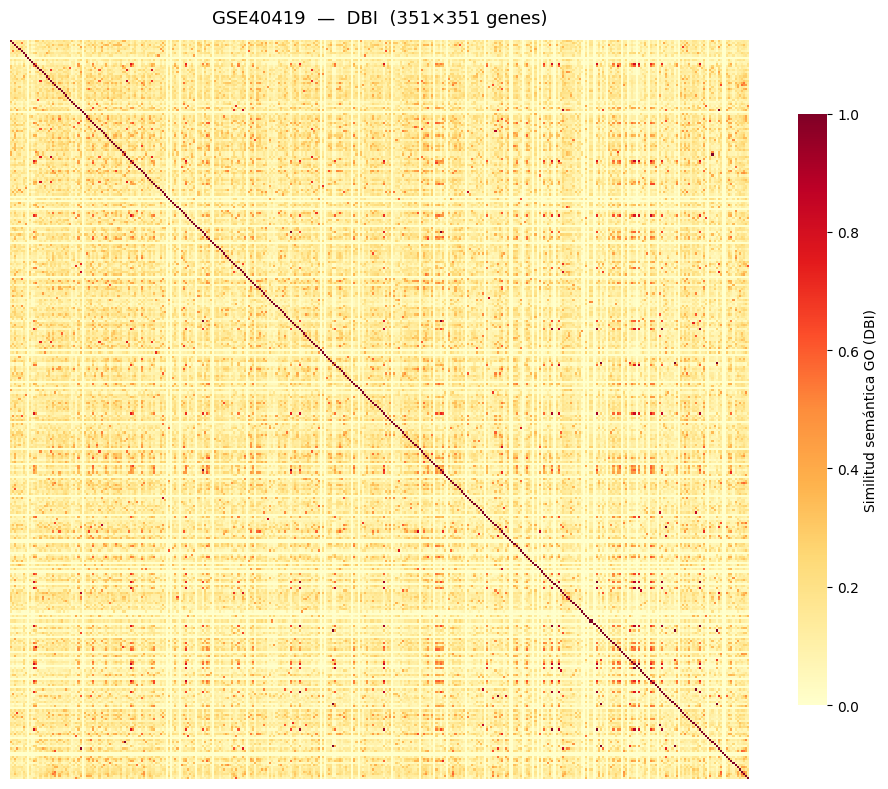

Heatmap guardado: C:\Users\benja\Desktop\workspace\Thesis\Datasets\DGE_DBI\heatmaps_dbi\GSE50760_DBI_heatmap.png


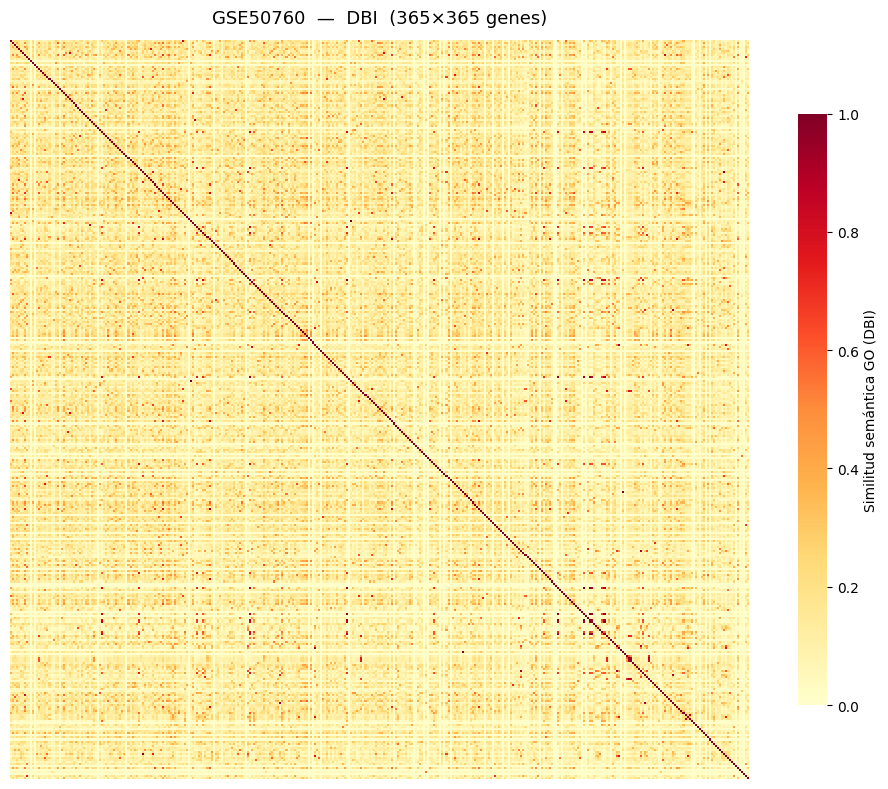

Heatmap guardado: C:\Users\benja\Desktop\workspace\Thesis\Datasets\DGE_DBI\heatmaps_dbi\GSE60052_DBI_heatmap.png


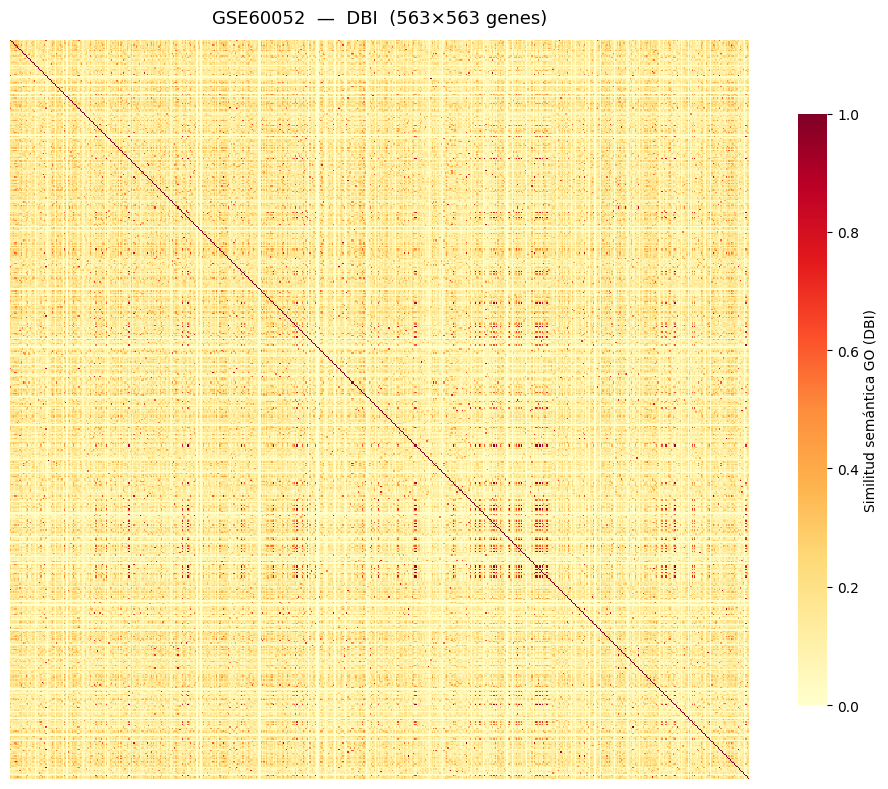

Heatmap guardado: C:\Users\benja\Desktop\workspace\Thesis\Datasets\DGE_DBI\heatmaps_dbi\GSE69240_DBI_heatmap.png


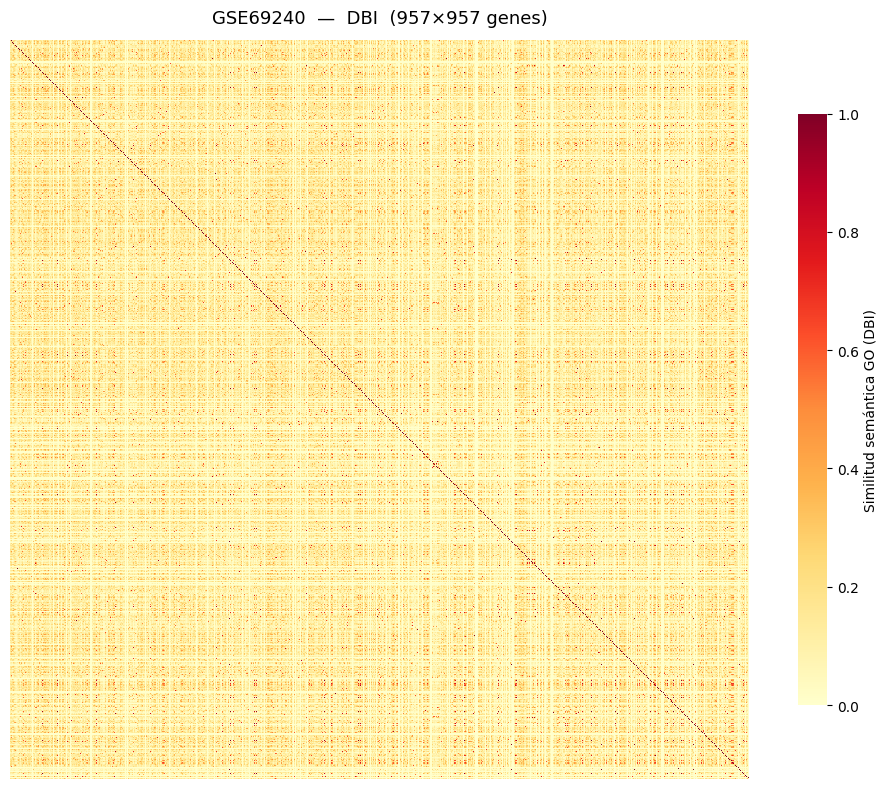

Heatmap guardado: C:\Users\benja\Desktop\workspace\Thesis\Datasets\DGE_DBI\heatmaps_dbi\GSE71651_DBI_heatmap.png


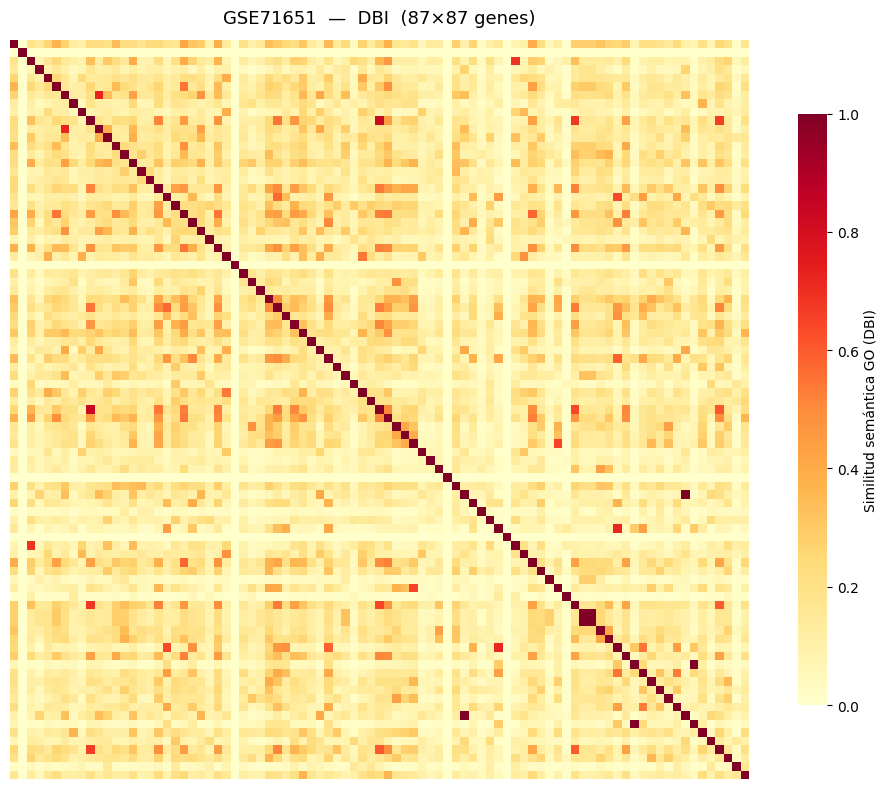

In [6]:
##################################
# PASO 3: Heatmaps de matrices DBI
##################################
import matplotlib.pyplot as plt
import seaborn as sns

HEATMAP_DIR = OUTPUT_DIR / "heatmaps_dbi"
HEATMAP_DIR.mkdir(exist_ok=True)

print(RESULTADOS)

for nombre, res in RESULTADOS.items():
    df   = res['DBI']
    n    = len(df)
    show_labels = n <= 50   # ocultar etiquetas si hay demasiados genes

    fig, ax = plt.subplots(figsize=(10, 8))

    sns.heatmap(
        df,
        ax          = ax,
        cmap        = "YlOrRd",
        vmin        = 0.0,
        vmax        = 1.0,
        xticklabels = show_labels,
        yticklabels = show_labels,
        cbar_kws    = {"label": "Similitud semántica GO (DBI)", "shrink": 0.8},
        square      = True,
        linewidths  = 0,
    )

    ax.set_title(f"{nombre}  —  DBI  ({n}×{n} genes)", fontsize=13, pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("")

    if show_labels:
        ax.tick_params(axis="x", rotation=90, labelsize=7)
        ax.tick_params(axis="y", rotation=0,  labelsize=7)

    plt.tight_layout()

    out_path = HEATMAP_DIR / f"{nombre}_DBI_heatmap.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Heatmap guardado: {out_path}")

    plt.show()
    plt.close(fig)